/var/folders/jr/s5cnc7wx3g9dkg38l2mjxft40000gn/T/ipykernel_33408/1038284999.py:14: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  male_16 = pd.read_csv("data/players_16.csv"); male_16["year"] = 2016
/var/folders/jr/s5cnc7wx3g9dkg38l2mjxft40000gn/T/ipykernel_33408/1038284999.py:16: DtypeWarning: Columns (81,82,83,84,85) have mixed types. Specify dtype option on import or set low_memory=False.
  male_18 = pd.read_csv("data/players_18.csv"); male_18["year"] = 2018


=== Peak Age (highest mean overall rating) ===
Female peak age: 40   mean overall: 85.0
Male   peak age: 33   mean overall: 69.5

=== Mean Development Gap (potential - overall) by age ===
Age 17 -> Female gap: 18.8   Male gap: 17.3
Age 22 -> Female gap: 8.2   Male gap: 8.0
Age 25 -> Female gap: 3.8   Male gap: 3.4
Age 30 -> Female gap: 0.0   Male gap: 0.0


/var/folders/jr/s5cnc7wx3g9dkg38l2mjxft40000gn/T/ipykernel_33408/1038284999.py:20: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  male_22 = pd.read_csv("data/players_22.csv"); male_22["year"] = 2022


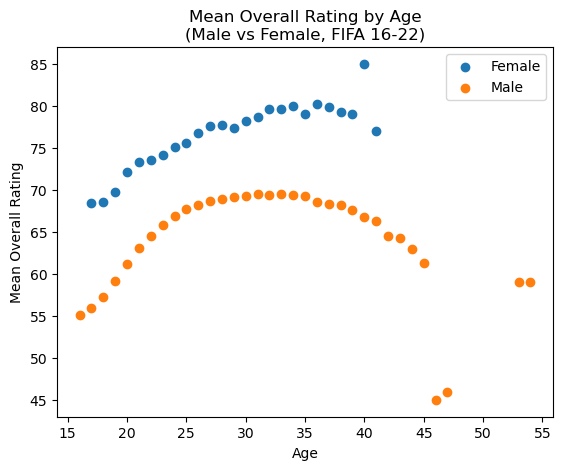

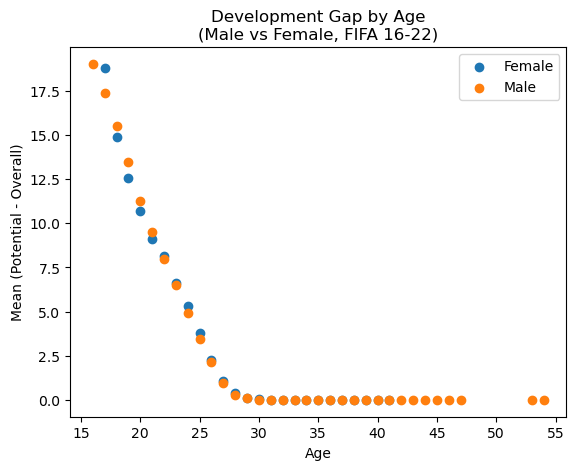

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Import & tag all datasets
female_16 = pd.read_csv("data/female_players_16.csv"); female_16["year"] = 2016
female_17 = pd.read_csv("data/female_players_17.csv"); female_17["year"] = 2017
female_18 = pd.read_csv("data/female_players_18.csv"); female_18["year"] = 2018
female_19 = pd.read_csv("data/female_players_19.csv"); female_19["year"] = 2019
female_20 = pd.read_csv("data/female_players_20.csv"); female_20["year"] = 2020
female_21 = pd.read_csv("data/female_players_21.csv"); female_21["year"] = 2021
female_22 = pd.read_csv("data/female_players_22.csv"); female_22["year"] = 2022

male_16 = pd.read_csv("data/players_16.csv"); male_16["year"] = 2016
male_17 = pd.read_csv("data/players_17.csv"); male_17["year"] = 2017
male_18 = pd.read_csv("data/players_18.csv"); male_18["year"] = 2018
male_19 = pd.read_csv("data/players_19.csv"); male_19["year"] = 2019
male_20 = pd.read_csv("data/players_20.csv"); male_20["year"] = 2020
male_21 = pd.read_csv("data/players_21.csv"); male_21["year"] = 2021
male_22 = pd.read_csv("data/players_22.csv"); male_22["year"] = 2022

# 2. Add gender label and stack everything together
female_all = pd.concat([female_16, female_17, female_18, female_19, female_20, female_21, female_22])
male_all   = pd.concat([male_16,   male_17,   male_18,   male_19,   male_20,   male_21,   male_22])

female_all["gender"] = "Female"
male_all["gender"]   = "Male"

cols = ["age", "overall", "potential", "gender"]
df = pd.concat([female_all[cols], male_all[cols]])

# 3. Split by gender
female_df = df.query("gender == 'Female'").copy()
male_df   = df.query("gender == 'Male'").copy()

# 4. Mean overall rating grouped by age
female_overall = female_df.groupby("age")["overall"].mean()
male_overall   = male_df.groupby("age")["overall"].mean()

# 5. Development gap (potential - overall)
female_df["gap"] = female_df["potential"] - female_df["overall"]
male_df["gap"]   = male_df["potential"]   - male_df["overall"]

female_gap = female_df.groupby("age")["gap"].mean()
male_gap   = male_df.groupby("age")["gap"].mean()

# 6. Print summary stats
print("=== Peak Age (highest mean overall rating) ===")
print("Female peak age:", female_overall.idxmax(),
      "  mean overall:", round(female_overall.max(), 1))
print("Male   peak age:", male_overall.idxmax(),
      "  mean overall:", round(male_overall.max(), 1))

print()
print("=== Mean Development Gap (potential - overall) by age ===")
for a in [17, 22, 25, 30]:
    fg = female_gap.get(a, float("nan"))
    mg = male_gap.get(a, float("nan"))
    print("Age", a, "-> Female gap:", round(fg, 1), "  Male gap:", round(mg, 1))

# 7. Plot 1: Mean overall rating by age
plt.scatter(x = female_overall.index, y = female_overall.values, label = "Female")
plt.scatter(x = male_overall.index,   y = male_overall.values,   label = "Male")
plt.xlabel("Age")
plt.ylabel("Mean Overall Rating")
plt.title("Mean Overall Rating by Age\n(Male vs Female, FIFA 16-22)")
plt.legend()
plt.show()

# 8. Plot 2: Development gap by age
plt.scatter(x = female_gap.index, y = female_gap.values, label = "Female")
plt.scatter(x = male_gap.index,   y = male_gap.values,   label = "Male")
plt.xlabel("Age")
plt.ylabel("Mean (Potential - Overall)")
plt.title("Development Gap by Age\n(Male vs Female, FIFA 16-22)")
plt.legend()
plt.show()